# 📈 Daily Trading System: Model Exploration & EDA
This notebook explores the historical financial data fetched from SimFin, performs Feature Engineering with Polars, and trains XGBoost models for price prediction.

**Objectives:**
1. Visualize stock price trends and distributions.
2. Understand the impact of technical indicators (SMA, Volatility).
3. Evaluate the performance of the 'Up/Down' classifier and Price regressor.

In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
from xgboost import XGBClassifier, XGBRegressor, plot_importance
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt

# Set theme for plotly
import plotly.io as pio
pio.templates.default = "plotly_white"

## 1. Data Loading & Initial Inspection

In [2]:
# Load the raw prices we fetched
df_raw = pl.read_parquet("../data/raw/prices.parquet")
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (7428, 11)


Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
str,i64,date,f64,f64,f64,f64,f64,i64,f64,i64
"""AAPL""",111052,2020-04-13,67.08,68.42,66.46,68.31,66.03,131022924,null,17295948000
"""AAPL""",111052,2020-04-14,70.0,72.06,69.51,71.76,69.37,194994688,null,17295948000
"""AAPL""",111052,2020-04-15,70.6,71.58,70.16,71.11,68.73,131154564,null,17295948000
"""AAPL""",111052,2020-04-16,71.84,72.05,70.59,71.67,69.28,157125160,null,17295948000
"""AAPL""",111052,2020-04-17,71.17,71.74,69.22,70.7,68.34,215249912,null,17337340000


## 2. Exploratory Data Analysis (EDA)
### 2.1 Price History
Let's look at how these companies have performed over the last 5 years.

In [4]:
fig_price = px.line(df_raw.to_pandas(), x="Date", y="Close", color="Ticker", 
                    title="Historical Close Prices (Normalized view available via Log Scale)",
                    labels={"Close": "Price ($)", "Date": "Year"})
fig_price.show()

### 2.2 Distribution of Daily Returns
Understanding volatility is key for trading models. Heavy tails in the distribution suggest high-risk periods.

In [5]:
# Calculate daily returns for visualization
df_returns = df_raw.with_columns([
    (pl.col("Close") / pl.col("Close").shift(1).over("Ticker") - 1).alias("Return")
]).drop_nulls()

fig_dist = px.histogram(df_returns.to_pandas(), x="Return", color="Ticker", marginal="box",
                        title="Distribution of Daily Returns", barmode="overlay",
                        labels={"Return": "Daily Percentage Change"})
fig_dist.show()

## 3. Feature Engineering & Correlation
We use Polars to calculate technical indicators. Let's see how these indicators correlate with our targets.

In [6]:
df_feat = pl.read_parquet("../data/processed/features.parquet")

# Correlation Heatmap (using Pandas for easier plotting)
corr_matrix = df_feat.select([
    "Close", "SMA_5", "SMA_20", "SMA_50", "Volatility_20", "Return_1d", "Target_Is_Up"
]).to_pandas().corr()

fig_corr = px.imshow(corr_matrix, text_auto=True, aspect="auto", 
                     title="Feature Correlation Matrix",
                     color_continuous_scale='RdBu_r')
fig_corr.show()

## 4. Model Performance & Evaluation
### 4.1 Feature Importance
Which indicators are driving the model's decisions?

<Figure size 1000x600 with 0 Axes>

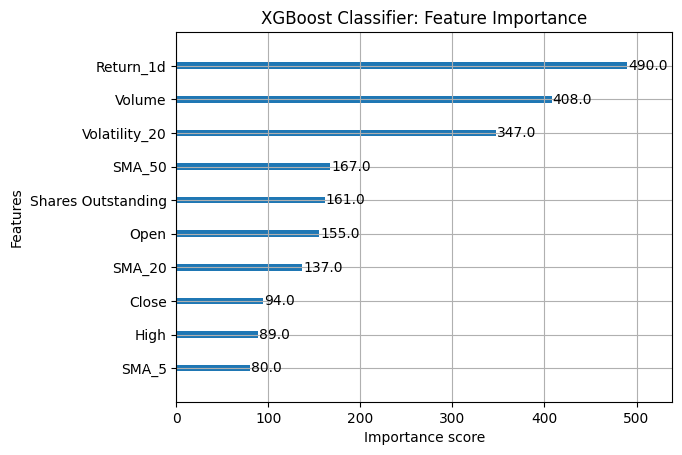

In [7]:
# Load trained classifier and features list
clf = joblib.load("../models/classifier.joblib")
features = joblib.load("../models/features_list.joblib")

# Plotting importance
plt.figure(figsize=(10, 6))
plot_importance(clf, max_num_features=10)
plt.title("XGBoost Classifier: Feature Importance")
plt.show()

### 4.2 Actual vs Predicted Prices (Regression)
Let's visualize the last 100 days of predictions for a specific ticker.

In [8]:
reg = joblib.load("../models/regressor.joblib")

# Prepare test data for one ticker (e.g., AAPL)
ticker_name = "AAPL"
df_ticker = df_feat.filter(pl.col("Ticker") == ticker_name).sort("Date")
X_test = df_ticker.select(features).to_pandas()
y_true = df_ticker["Target_Next_Price"].to_pandas()
y_pred = reg.predict(X_test)

fig_reg = go.Figure()
fig_reg.add_trace(go.Scatter(x=df_ticker["Date"].to_list()[-100:], y=y_true.iloc[-100:], name="Actual Price"))
fig_reg.add_trace(go.Scatter(x=df_ticker["Date"].to_list()[-100:], y=y_pred[-100:], name="Predicted Price", line=dict(dash='dash')))
fig_reg.update_layout(title=f"{ticker_name}: Actual vs Predicted Next-Day Price (Last 100 Days)",
                      xaxis_title="Date", yaxis_title="Price ($)")
fig_reg.show()

## 5. Summary & Next Steps
- The **Classification** model acts as our 'Trading Signal' generator.
- The **Regression** model helps us estimate the magnitude of the move.
- **Improvements to consider:**
    - Adding more features (RSI, MACD).
    - Hyperparameter tuning using Optuna.
    - Sector-specific normalization.